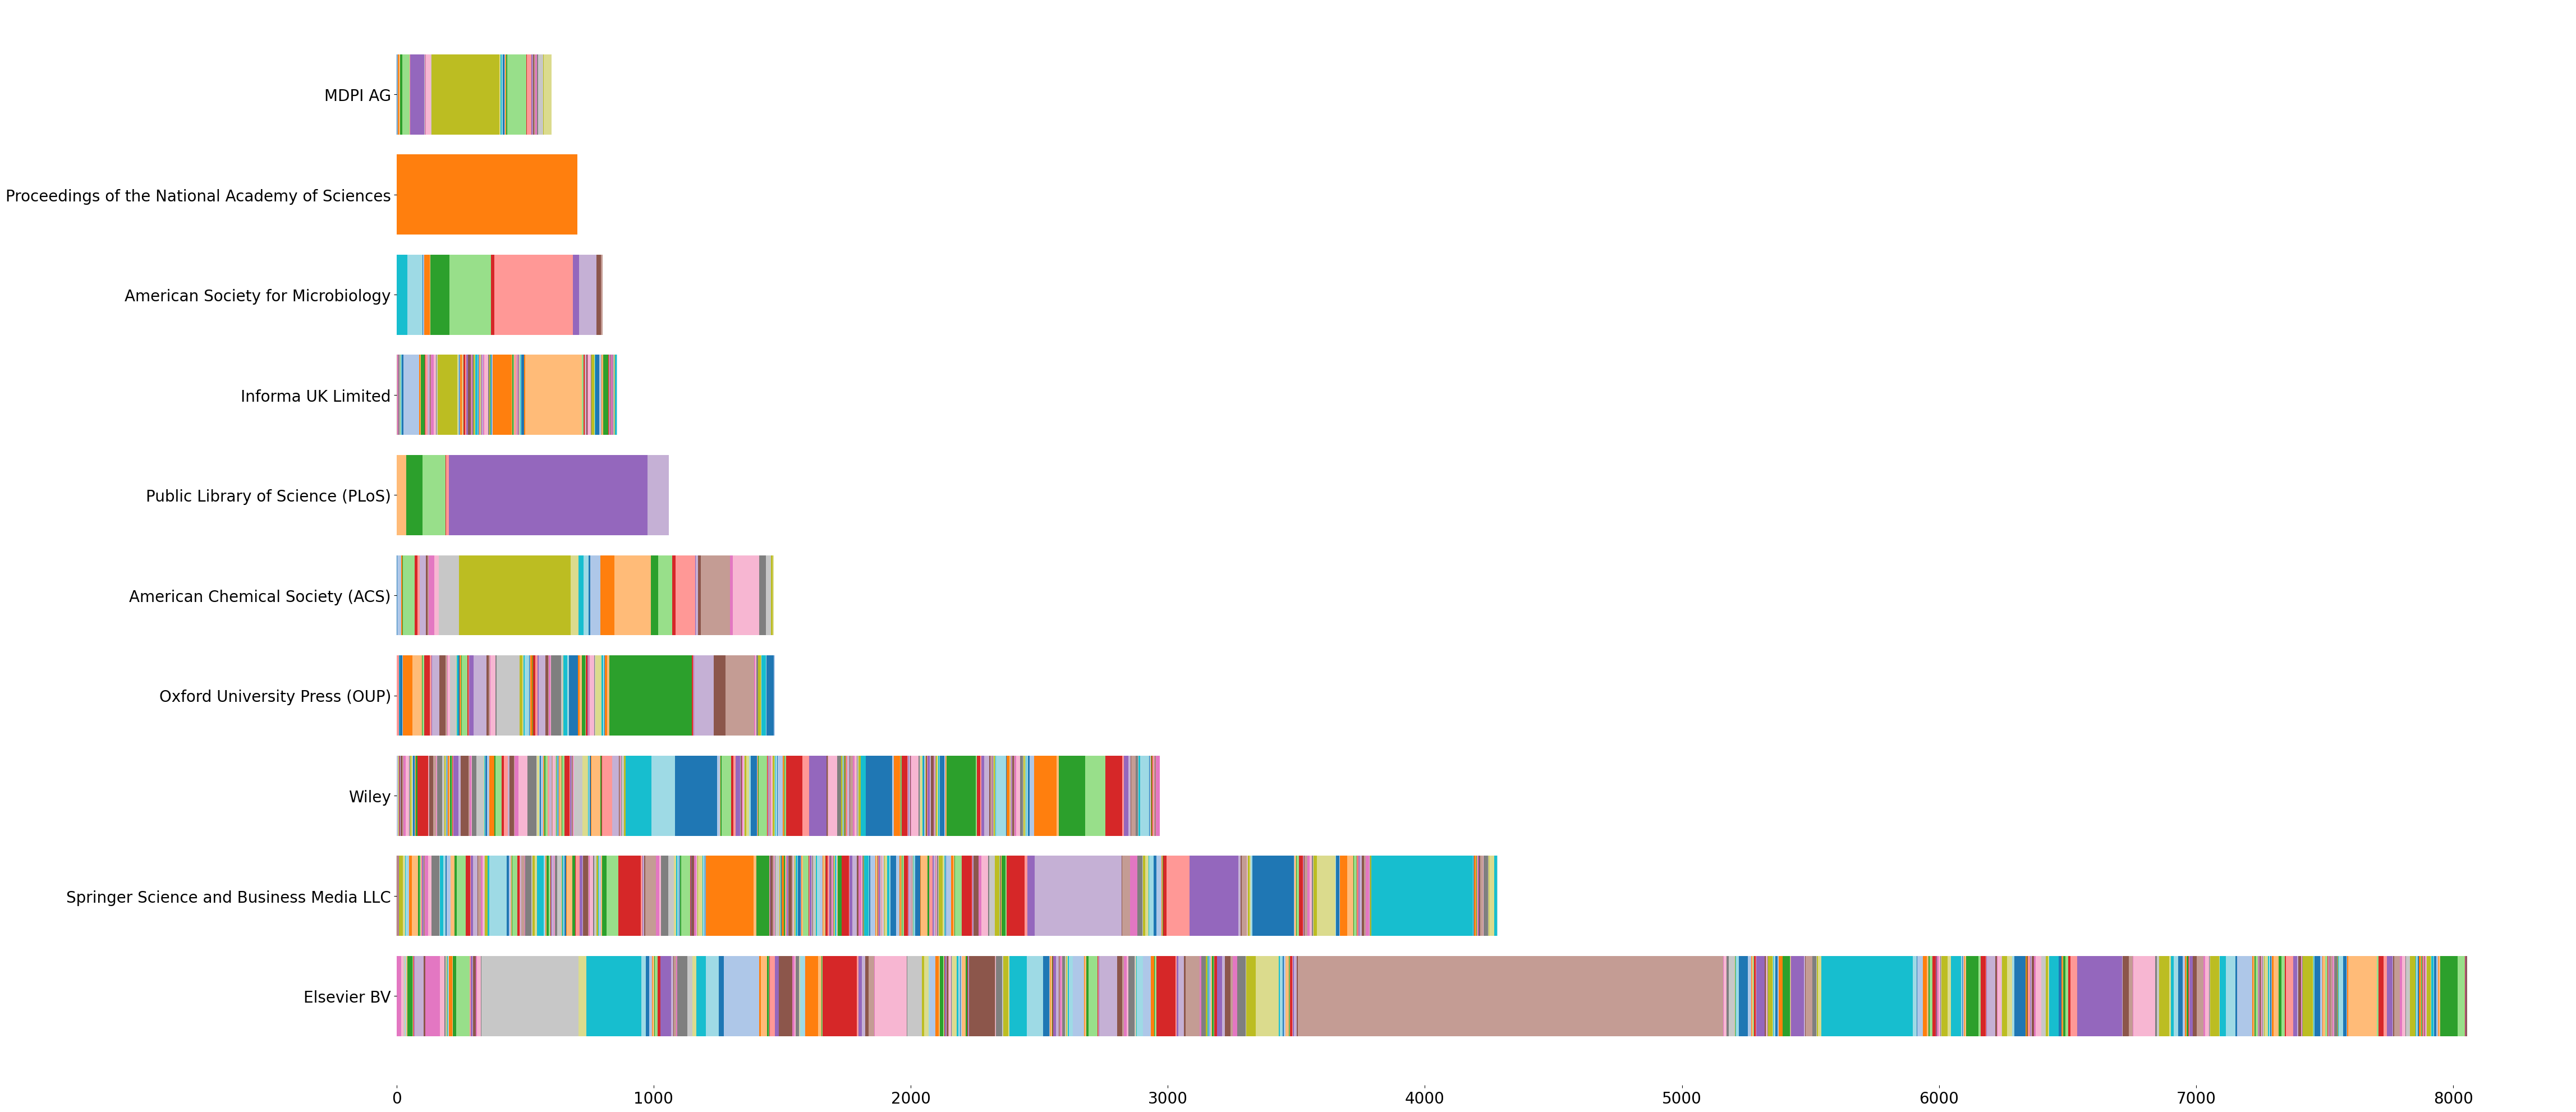

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# Load the dataset
df = pd.read_csv("/pmid_doi_journal_publisher_30k.csv")

# group by publisher and journal for the plot and reset index
publisher_journal_summary = (
    df.groupby(['publisher', 'journal'])
    .agg(total_pmids=('pmid', 'count'))
    .reset_index()
)

# top 10 publishers
publisher_order = (
    publisher_journal_summary
    .groupby('publisher')['total_pmids']
    .sum()
    .sort_values(ascending=False)
    .index
)
top_10_publishers = publisher_order[:10]
publisher_journal_summary = publisher_journal_summary[publisher_journal_summary['publisher'].isin(top_10_publishers)]

# Create a color palette with a unique color for each journal/needs work
unique_journals = publisher_journal_summary['journal'].unique()
colors = sns.color_palette('tab20', len(unique_journals))
color_dict = dict(zip(unique_journals, colors))

# Initialize the matplotlib figure
f, ax = plt.subplots(figsize=(50, 25))

# Sort the publishers by their total PMIDs
sorted_publishers = publisher_journal_summary.groupby('publisher')['total_pmids'].sum().sort_values(ascending=False).index

# Create a stacked bar plot
bottom_dict = {publisher: 0 for publisher in sorted_publishers}
for journal in unique_journals:
    journal_data = publisher_journal_summary[publisher_journal_summary['journal'] == journal]
    ax.barh(
    [list(sorted_publishers).index(publisher) for publisher in journal_data['publisher']],
    journal_data['total_pmids'],
    left=[bottom_dict[publisher] for publisher in journal_data['publisher']],
    color=color_dict[journal],
    label=journal
)
    
    for publisher in journal_data['publisher']:
        bottom_dict[publisher] += journal_data[journal_data['publisher'] == publisher]['total_pmids'].values[0]

ax.set_yticks(range(len(sorted_publishers)))
ax.set_yticklabels(sorted_publishers)

sns.despine(left=True, bottom=True)


# Set the font size
plt.rc('font', size=20) 

plt.show()
